# 유방암(Breast) 임상 코호트 분석

**목표.** 진행 중인 유방암(Breast) 임상 코호트를 ClinicalTrials.gov 전량 수집 데이터로 분석하여,
(1) 표준치료 **B(대조군/backbone)** 데이터 자산을 수요 폭 기준으로 우선순위화하고,
(2) **코호트 유사도 2D 맵 + 군집화**로 제약사들이 집중하는 코호트 분포를 시각화한다.
빅파마 참여 임상을 강조 표시해 **먼저 접근할 코호트**를 선별한다.

핵심 통찰: `A + B vs B`(또는 `A vs B`) 구조에서 **B는 표준치료**이며, 스폰서들은 공통적으로
"B 치료에 따른 종양미세환경(TME) 변화·반응 바이오마커"를 원한다 → B의 실제 TME 데이터는
그 B를 쓰는 진행 중 임상이 많을수록 가치가 높다.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"

from cancer_config import current
CFG = current(); SLUG = CFG["slug"]; CANCER = CFG["name"]; BM_COLS_ALL = CFG["bm_cols"]

df = pd.read_csv(ROOT / "data" / f"cohorts_{SLUG}_features.csv")
# 제약사(INDUSTRY) 주도 임상만 — 학술기관/비영리 스폰서 제외
n_all = len(df)
df = df[df.is_industry == 1].reset_index(drop=True)
print(f"{CANCER}: industry-led trials {len(df)} / {n_all} (academic/other excluded)")
df.head(3)

Breast: industry-led trials 586 / 883 (academic/other excluded)


,nct_id,brief_title,phase,phase_simple,overall_status,enrollment,lead_sponsor,company,sponsor_scale,is_industry,...,HR/ER,HER2,PD-L1,BRCA/HRD,PIK3CA,first_line,later_line,biomarker_selected,biomarker_detail,elig_summary
0,NCT00099437,Comparison of Fulvestrant (FASLODEX™) 250 mg a...,PHASE3,Phase 3,ACTIVE_NOT_RECRUITING,736,AstraZeneca,AstraZeneca,780,1,...,1,0,0,0,0,0,0,1,HR+,advanced
1,NCT00248287,PhII ICb With/Without Erbitux in MBC Pts,PHASE2,Phase 2,ACTIVE_NOT_RECRUITING,154,US Oncology Research,US Oncology Research,24,1,...,0,1,0,0,0,1,0,1,HER2+,metastatic · 1st-line · measurable (RECIST)
2,NCT01872260,"Study of LEE011, BYL719 and Letrozole in Advan...",PHASE1;PHASE2,Phase 2,ACTIVE_NOT_RECRUITING,259,Novartis Pharmaceuticals,Novartis,836,1,...,0,1,0,0,0,0,0,1,HER2+,metastatic


## 1. EDA — 수집 데이터 분포 점검

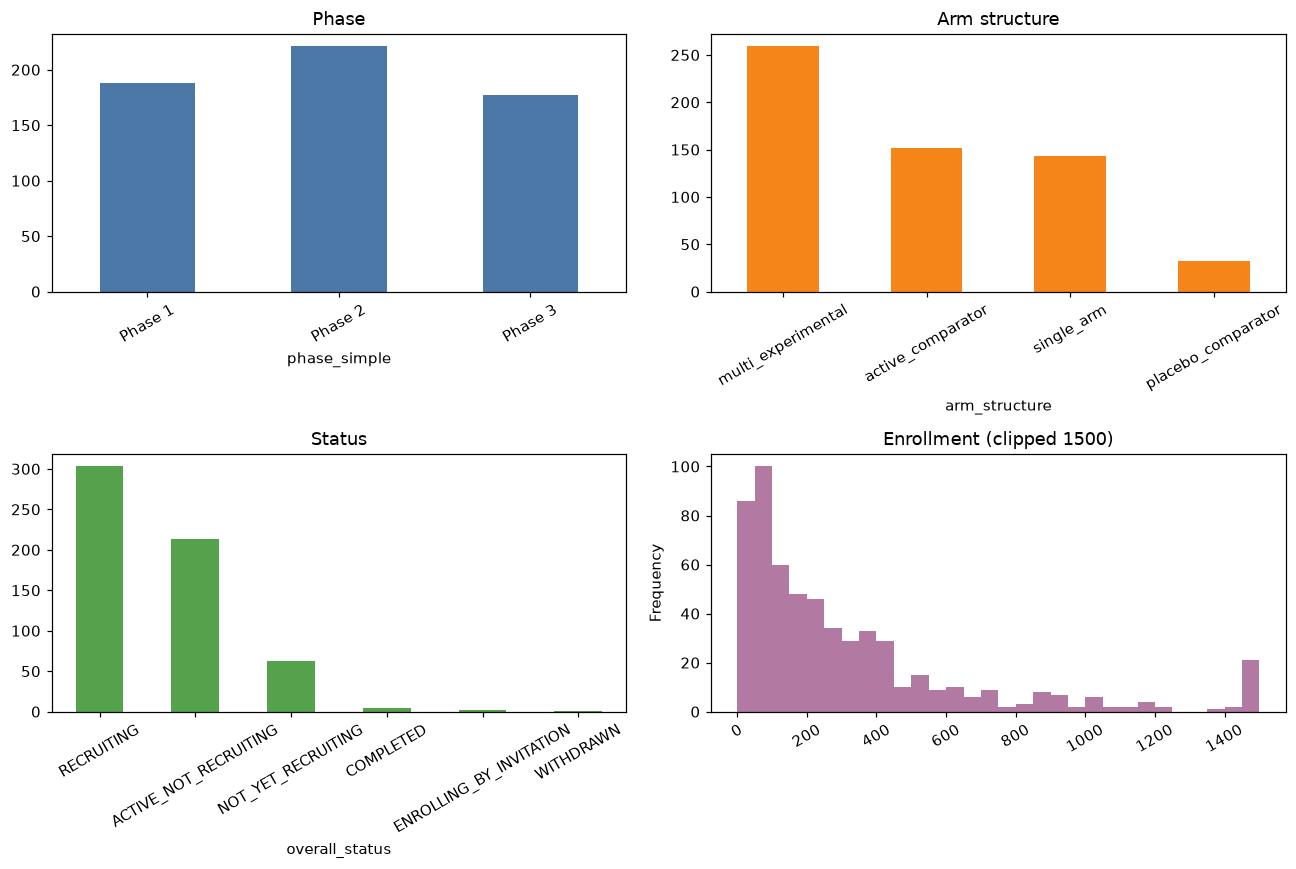

Industry-led: 586 | Big pharma involved: 192
TME-relevant modality: 233 | Biomarker-selected eligibility: 442


In [2]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
df.phase_simple.value_counts().reindex(["Phase 1","Phase 2","Phase 3"]).plot.bar(ax=ax[0,0], color="#4C78A8"); ax[0,0].set_title("Phase")
df.arm_structure.value_counts().plot.bar(ax=ax[0,1], color="#F58518"); ax[0,1].set_title("Arm structure")
df.overall_status.value_counts().plot.bar(ax=ax[1,0], color="#54A24B"); ax[1,0].set_title("Status")
df.enrollment.clip(upper=1500).plot.hist(bins=30, ax=ax[1,1], color="#B279A2"); ax[1,1].set_title("Enrollment (clipped 1500)")
for a in ax.ravel(): a.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

print("Industry-led:", int((df.lead_sponsor.notna()).sum()), "| Big pharma involved:", int(df.is_big_pharma.sum()))
print("TME-relevant modality:", int(df.tme_relevant.sum()), "| Biomarker-selected eligibility:", int(df.biomarker_selected.sum()))

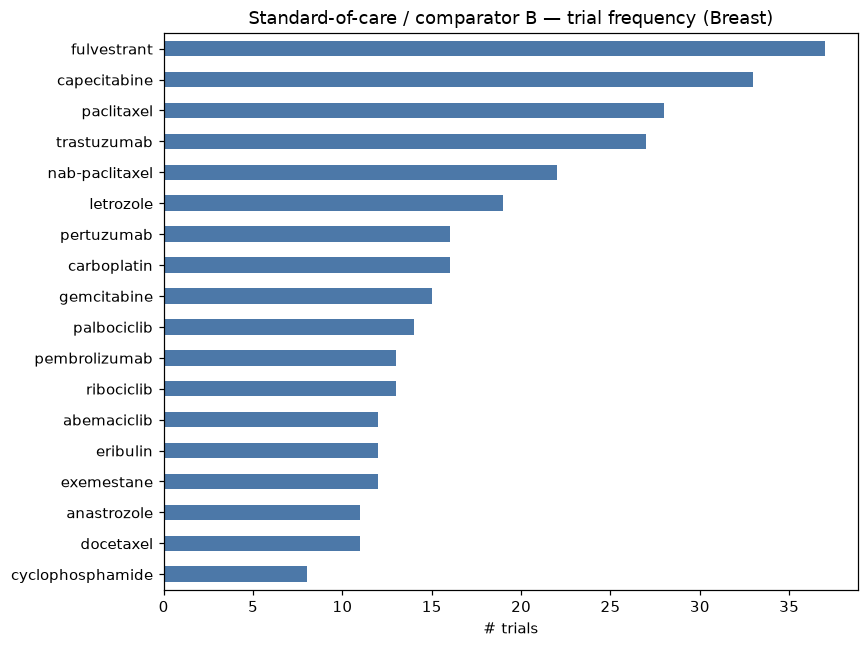

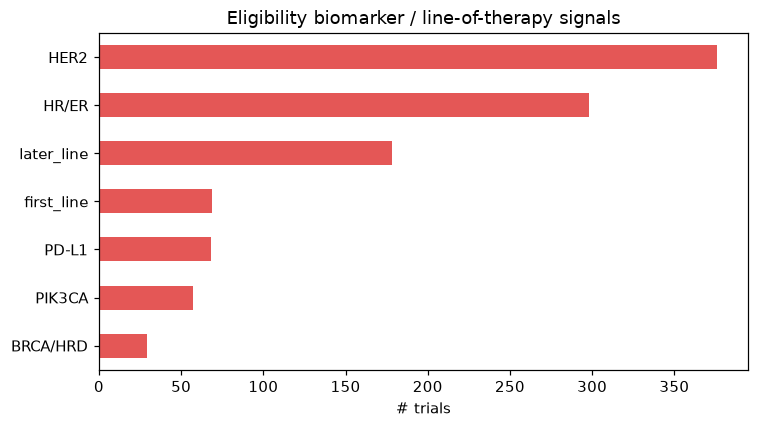

In [3]:
from collections import Counter
cb = Counter(x for s in df.comparator_B.dropna() for x in s.split(";") if x)
top_b = pd.Series(dict(cb.most_common(18)))
ax = top_b.iloc[::-1].plot.barh(figsize=(8,6), color="#4C78A8")
ax.set_title(f"Standard-of-care / comparator B — trial frequency ({CANCER})"); ax.set_xlabel("# trials"); plt.tight_layout(); plt.show()

bm = df[[c for c in BM_COLS_ALL + ["first_line","later_line"] if c in df]].sum().sort_values()
ax = bm.plot.barh(figsize=(7,4), color="#E45756"); ax.set_title("Eligibility biomarker / line-of-therapy signals"); ax.set_xlabel("# trials"); plt.tight_layout(); plt.show()

## 1-B. 표준치료(SoC) 대조군 코호트 분류 (정규화 보정 포함)

각 임상의 대조군/backbone을 스캔해 **확립된 표준치료(SoC)가 있는 코호트**와 아닌 것으로 나눈다.
레지멘 변형(`FLOT regimen`), 복합 표기(`trastuzumab + XELOX`), generic 표기(`standard of care`,
`investigator's choice`)까지 substring으로 인식해 정규화 누락을 보정한다.
비-SoC는 ① 대조군 없음(단일군/비대조), ② novel 신약만, ③ 비약물(수술·기기·진단)으로 세분한다.

cohort_class
novel drug only (no SoC)        341
SoC-anchored                    228
non-drug (surgery/device/dx)     17

SoC-anchored: 228 / 586


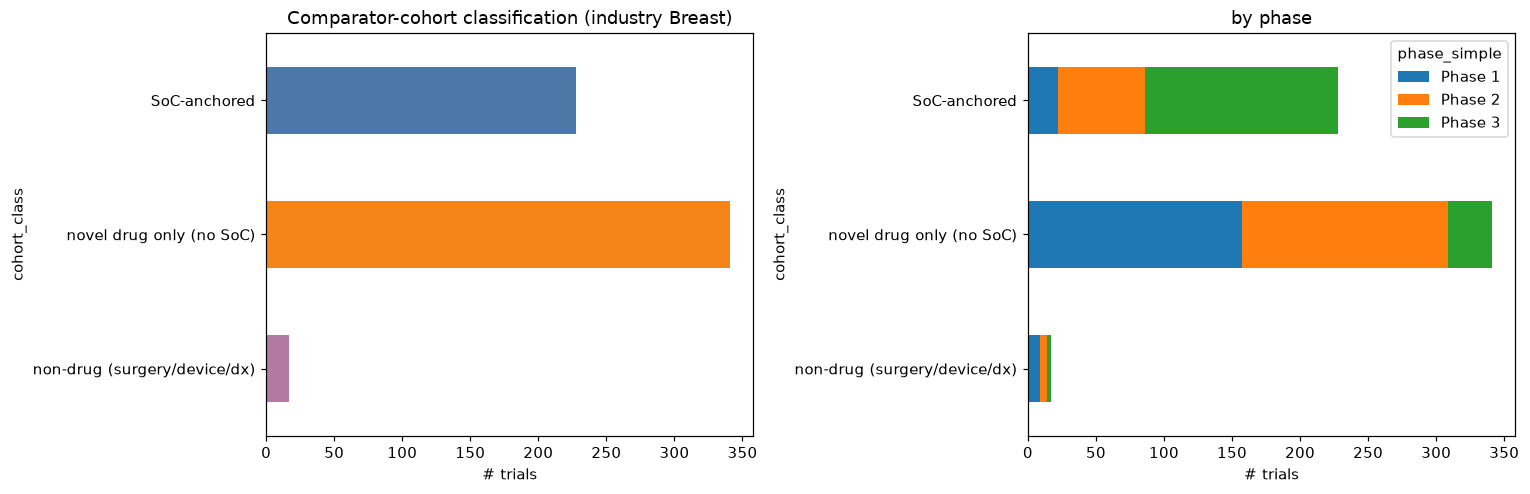


SoC-anchored 코호트의 치료 계열 분포:
soc_class
chemo                     51
chemo;endocrine           34
HER2;chemo                24
HER2                      23
endocrine                 13
CDK4/6                    10
IO;chemo                   9
CDK4/6;chemo;endocrine     9
PARP                       8
CDK4/6;endocrine           8
SoC_generic                7
chemo;endocrine;mTOR       6


In [4]:
from drug_normalize import soc_from_text, soc_classes, NONDRUG_HINTS, SOC_GENERIC_TOKEN

soc_sets = df.comparator_B.fillna("").apply(soc_from_text)
df["B_soc"] = soc_sets.apply(lambda s: ";".join(sorted(s)))
df["soc_class"] = soc_sets.apply(lambda s: ";".join(sorted(soc_classes(s))))
df["has_soc"] = (df.soc_class != "").astype(int)

def categorize(r):
    if r.has_soc: return "SoC-anchored"
    cb = str(r.comparator_B or "").strip()
    if cb == "": return "no comparator (uncontrolled)"
    if any(h in cb.lower() for h in NONDRUG_HINTS): return "non-drug (surgery/device/dx)"
    return "novel drug only (no SoC)"
df["cohort_class"] = df.apply(categorize, axis=1)

vc = df.cohort_class.value_counts()
print(vc.to_string()); print("\nSoC-anchored:", int(df.has_soc.sum()), "/", len(df))

order = ["SoC-anchored","novel drug only (no SoC)","non-drug (surgery/device/dx)","no comparator (uncontrolled)"]
order = [o for o in order if o in vc.index]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
vc.reindex(order).plot.barh(ax=ax[0], color=["#4C78A8","#F58518","#B279A2","#9D9D9D"][:len(order)])
ax[0].set_title(f"Comparator-cohort classification (industry {CANCER})"); ax[0].set_xlabel("# trials"); ax[0].invert_yaxis()
pd.crosstab(df.cohort_class, df.phase_simple).reindex(order).plot.barh(stacked=True, ax=ax[1])
ax[1].set_title("by phase"); ax[1].set_xlabel("# trials"); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

print("\nSoC-anchored 코호트의 치료 계열 분포:")
print(df[df.has_soc==1].soc_class.value_counts().head(12).to_string())

## 2. Feature engineering — 표준치료 **성분(component)** 인코딩

**바이오마커·타겟·모달리티·arm 구조 등은 제외.** SoC-anchored 코호트만 남긴다.
군집화 feature는 표준치료를 **성분 약물 수준**으로 인코딩한다(FOLFOX→5FU+leucovorin+oxaliplatin).
이유: 레지멘을 원자 feature로 두면 "3개 중 2개만" 쓴 케이스나 유사 레지멘이 코사인 유사도 0으로
분리되지만, 성분으로 두면 **부분 겹침이 반영**돼 임상적으로 가까운 코호트가 가깝게 위치한다.
레지멘 라벨(`B_soc`)은 클러스터 해석·카드 표시용으로만 유지.

In [5]:
from drug_normalize import to_components

def multihot(series, prefix, top=None):
    lists = series.fillna("").apply(lambda s: [x for x in s.split(";") if x])
    vocab = Counter(x for l in lists for x in l)
    keys = [k for k,_ in vocab.most_common(top)] if top else sorted(vocab)
    return pd.DataFrame({f"{prefix}={k}": lists.apply(lambda l: int(k in l)) for k in keys}, index=series.index)

n_before = len(df)
df = df[df.has_soc == 1].reset_index(drop=True)
print(f"standard-of-care anchored cohorts: {len(df)}  (from {n_before} industry {CANCER} trials)")

df["B_comp"] = df.B_soc.apply(lambda s: ";".join(sorted(to_components(s.split(";")))))
X = multihot(df.B_comp, "B")
print("feature matrix (SoC components):", X.shape)
print("성분 feature:", list(X.columns))

standard-of-care anchored cohorts: 228  (from 586 industry Breast trials)
feature matrix (SoC components): (228, 41)
성분 feature: ['B=abemaciclib', 'B=anastrozole', 'B=atezolizumab', 'B=capecitabine', 'B=carboplatin', 'B=cetuximab', 'B=cyclophosphamide', 'B=docetaxel', 'B=doxorubicin', 'B=durvalumab', 'B=entrectinib', 'B=epirubicin', 'B=eribulin', 'B=everolimus', 'B=exemestane', 'B=fluorouracil', 'B=fulvestrant', 'B=gemcitabine', 'B=goserelin', 'B=irinotecan', 'B=lapatinib', 'B=letrozole', 'B=leuprolide', 'B=liposomal doxorubicin', 'B=nab-paclitaxel', 'B=niraparib', 'B=nivolumab', 'B=olaparib', 'B=paclitaxel', 'B=palbociclib', 'B=pembrolizumab', 'B=pertuzumab', 'B=ribociclib', 'B=s-1', 'B=sacituzumab govitecan', 'B=standard_of_care', 'B=tamoxifen', 'B=trastuzumab', 'B=trastuzumab deruxtecan', 'B=tucatinib', 'B=vinorelbine']


## 2-B. 레지멘 수준 데이터 (별도 표시)

군집은 성분 기반이지만, 사람이 읽기 좋은 **레지멘 관점**으로도 따로 집계한다:
각 코호트의 **화학요법 backbone**과 **추가 표적·면역 약물**(+anti-VEGF/+anti-EGFR/+IO/+HER2/+CLDN18.2)을
조합해 분포를 본다.

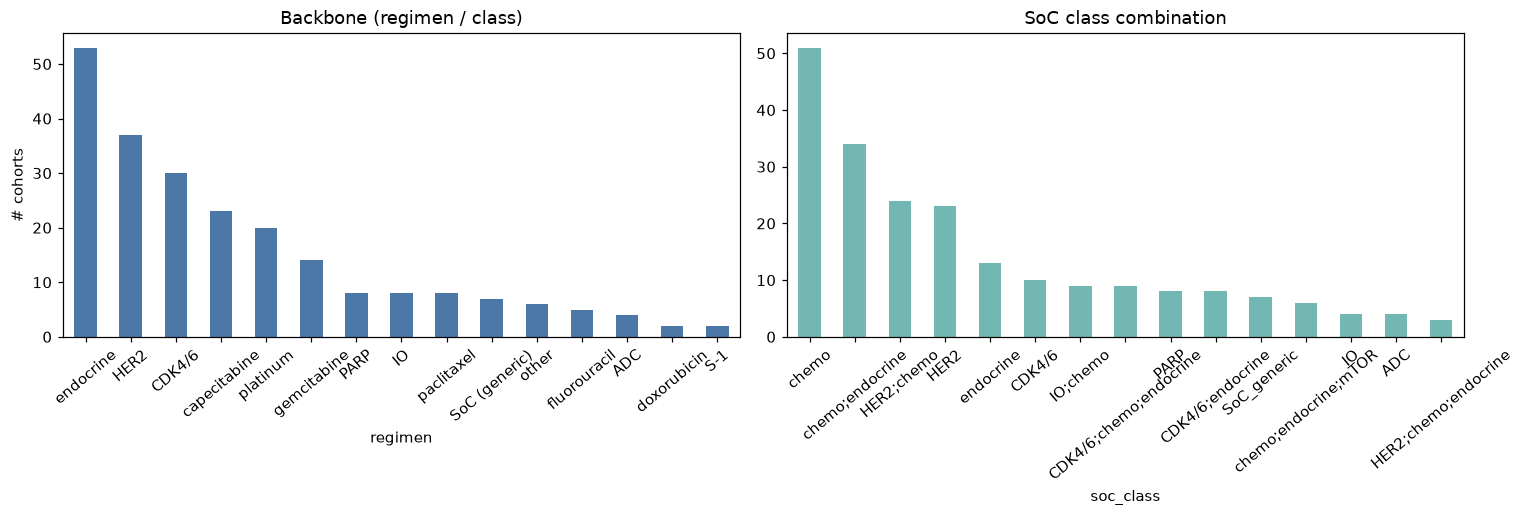

Backbone × 추가 표적/IO 계열 (상위):
regimen_add    ADC  AR_targeted + endocrine  CDK4/6  HER2  IO  IO + PARP  anti_EGFR  endocrine  mTOR   —
regimen                                                                                                 
ADC              0                        0       0     0   0          0          0          0     0   4
ALK/ROS1_TKI     0                        0       0     0   0          0          0          0     0   1
CDK4/6           0                        2       0     0   0          0          1         17     0  10
HER2             0                        0       1     0   0          0          0          3     0  33
IO               0                        0       1     1   0          0          0          0     0   6
PARP             0                        0       0     0   0          0          0          0     0   8
S-1              0                        0       0     0   0          0          0          0     0   2
SoC (generic)    0        

In [6]:
REG_SET = {"FOLFOX","FOLFIRI","FOLFOXIRI","FOLFIRINOX","CAPOX","CAPIRI",
           "FLOT","SOX","FP","XP","ECF","ECX","TPF"}
# non-chemo class priority for naming the backbone of a targeted/IO cohort
PREF = ["IO","EGFR_TKI","ALK/ROS1_TKI","KRAS_G12Ci","MET_TKI","RET_TKI","HER2","CLDN18.2",
        "CDK4/6","endocrine","AR_targeted","PARP","VEGFR_TKI","anti_VEGF","anti_EGFR",
        "mTOR","SSTR","FGFR_TKI","ADC","BRAF_MEK","radioligand"]
b_lists = df.B_soc.apply(lambda s:[x for x in s.split(";") if x])
def backbone(l):
    s=set(l); r=[x for x in l if x in REG_SET]
    if r: return r[0]
    if {"fluorouracil","leucovorin"} <= s: return "5FU/LV"
    if s & {"carboplatin","cisplatin"}: return "platinum"
    if "s-1" in s: return "S-1"
    if "gemcitabine" in s: return "gemcitabine"
    if "capecitabine" in s: return "capecitabine"
    if "trifluridine/tipiracil" in s: return "TAS-102"
    if "temozolomide" in s: return "temozolomide"
    if "doxorubicin" in s: return "doxorubicin"
    cls=[c for c in soc_classes(l) if c not in ("chemo","SoC_generic")]
    for p in PREF:
        if p in cls: return p
    if cls: return sorted(cls)[0]
    if "standard_of_care" in s: return "SoC (generic)"
    if len(s)==1: return next(iter(s))
    return "other"
def addition(l, bb):
    adds=sorted(c for c in soc_classes(l) if c not in ("chemo","SoC_generic") and c!=bb)
    return " + ".join(adds) if adds else "—"
df["regimen"] = b_lists.apply(backbone)
df["regimen_add"] = df.apply(lambda r:[x for x in r.B_soc.split(";") if x], axis=1).apply(lambda l: addition(l, backbone(l)))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
df.regimen.value_counts().head(15).plot.bar(ax=ax[0], color="#4C78A8"); ax[0].set_title("Backbone (regimen / class)"); ax[0].set_ylabel("# cohorts"); ax[0].tick_params(axis="x", rotation=40)
df.soc_class.value_counts().head(15).plot.bar(ax=ax[1], color="#72B7B2"); ax[1].set_title("SoC class combination"); ax[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.show()

print("Backbone × 추가 표적/IO 계열 (상위):")
print(pd.crosstab(df.regimen, df.regimen_add).head(20).to_string())

## 3. 차원축소 & 군집화 — 치료구성 cosine 공간에서 KMeans (silhouette로 k 선택)

In [7]:
from sklearn.preprocessing import normalize
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 표준치료는 동질적 → 표준화/PCA는 희소 feature를 과대평가해 blob 발생.
# 치료 '구성' 유사도(cosine) 공간에서 군집화하면 균형 잡힌 아키타입이 나온다.
EMB = normalize(X.values.astype(float))

best_k, best_s = None, -1
for k in range(4, min(9, max(4, len(df)//8)) + 1):
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(EMB)
    s = silhouette_score(EMB, lab)
    print(f"k={k}  silhouette={s:.3f}  sizes={sorted(np.bincount(lab), reverse=True)}")
    if s > best_s: best_k, best_s = k, s
print("chosen k =", best_k)
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(EMB)
df["cluster"] = km.labels_

perp = max(5, min(30, (len(df)-1)//3))
tsne = TSNE(n_components=2, perplexity=perp, init="pca", random_state=0,
            learning_rate="auto", metric="cosine")
XY = tsne.fit_transform(EMB)
rng = np.random.default_rng(0)
jit = (XY.max(0)-XY.min(0)) * 0.015
df["x"] = XY[:,0] + rng.normal(0, jit[0], len(df))
df["y"] = XY[:,1] + rng.normal(0, jit[1], len(df))

k=4  silhouette=0.295  sizes=[np.int64(68), np.int64(60), np.int64(57), np.int64(43)]
k=5  silhouette=0.304  sizes=[np.int64(68), np.int64(57), np.int64(40), np.int64(38), np.int64(25)]
k=6  silhouette=0.316  sizes=[np.int64(54), np.int64(52), np.int64(42), np.int64(35), np.int64(26), np.int64(19)]
k=7  silhouette=0.329  sizes=[np.int64(54), np.int64(45), np.int64(38), np.int64(26), np.int64(23), np.int64(21), np.int64(21)]
k=8  silhouette=0.349  sizes=[np.int64(54), np.int64(50), np.int64(35), np.int64(26), np.int64(21), np.int64(21), np.int64(14), np.int64(7)]
k=9  silhouette=0.346  sizes=[np.int64(50), np.int64(38), np.int64(32), np.int64(28), np.int64(23), np.int64(21), np.int64(21), np.int64(9), np.int64(6)]
chosen k = 8


## 4. 클러스터 프로파일링 — 아키타입 명명

In [8]:
def top_tokens(sub, col, n=3):
    c = Counter(x for s in sub[col].dropna() for x in s.split(";") if x)
    return ", ".join(k for k,_ in c.most_common(n)) or "-"

prof = []
for c in sorted(df.cluster.unique()):
    sub = df[df.cluster==c]
    prof.append({
        "cluster": c, "n": len(sub),
        "top_B": top_tokens(sub, "B_soc"),
        "top_target": top_tokens(sub, "targets"),
        "top_modality": top_tokens(sub, "modalities"),
        "phase_mix": ", ".join(f"{k}:{v}" for k,v in sub.phase_simple.value_counts().items()),
        "bigpharma": int(sub.is_big_pharma.sum()),
        "biomarker_sel%": round(100*sub.biomarker_selected.mean()),
    })
prof = pd.DataFrame(prof)
prof

,cluster,n,top_B,top_target,top_modality,phase_mix,bigpharma,biomarker_sel%
0,0,54,"fluorouracil, fulvestrant, everolimus","PI3K, CDK4/6, HER2","Small Molecule, ADC, Recombinant Protein","Phase 3:29, Phase 2:17, Phase 1:8",27,93
1,1,21,"pertuzumab, trastuzumab, docetaxel","HER2, PD-1, PI3K","Monoclonal Antibody, ADC, Small Molecule","Phase 3:16, Phase 2:5",4,100
2,2,50,"capecitabine, pembrolizumab, olaparib","PARP, CDK4/6, PD-1","Small Molecule, Monoclonal Antibody, ADC","Phase 2:24, Phase 3:17, Phase 1:9",34,82
3,3,26,"letrozole, anastrozole, exemestane","CDK4/6, ESR1, HER2",Small Molecule,"Phase 3:23, Phase 2:3",15,88
4,4,7,standard_of_care,"Globo H, ESR1, HER2","Small Molecule, Peptide, Monoclonal Antibody","Phase 3:6, Phase 2:1",3,86
5,5,35,"paclitaxel, nab-paclitaxel, capecitabine","PD-1, HER2, PD-L1","ADC, Monoclonal Antibody, Small Molecule","Phase 3:28, Phase 2:5, Phase 1:2",17,86
6,6,14,"capecitabine, eribulin, vinorelbine","HER2, TROP2, CD47","ADC, Monoclonal Antibody, Bispecific Antibody","Phase 3:12, Phase 2:2",2,93
7,7,21,"trastuzumab, trastuzumab deruxtecan, tucatinib","HER2, PD-L1, EGFR","ADC, Monoclonal Antibody, Small Molecule","Phase 3:11, Phase 2:7, Phase 1:3",13,100


## 5. 코호트 유사도 2D 맵 — 클러스터 · Phase · 빅파마 강조

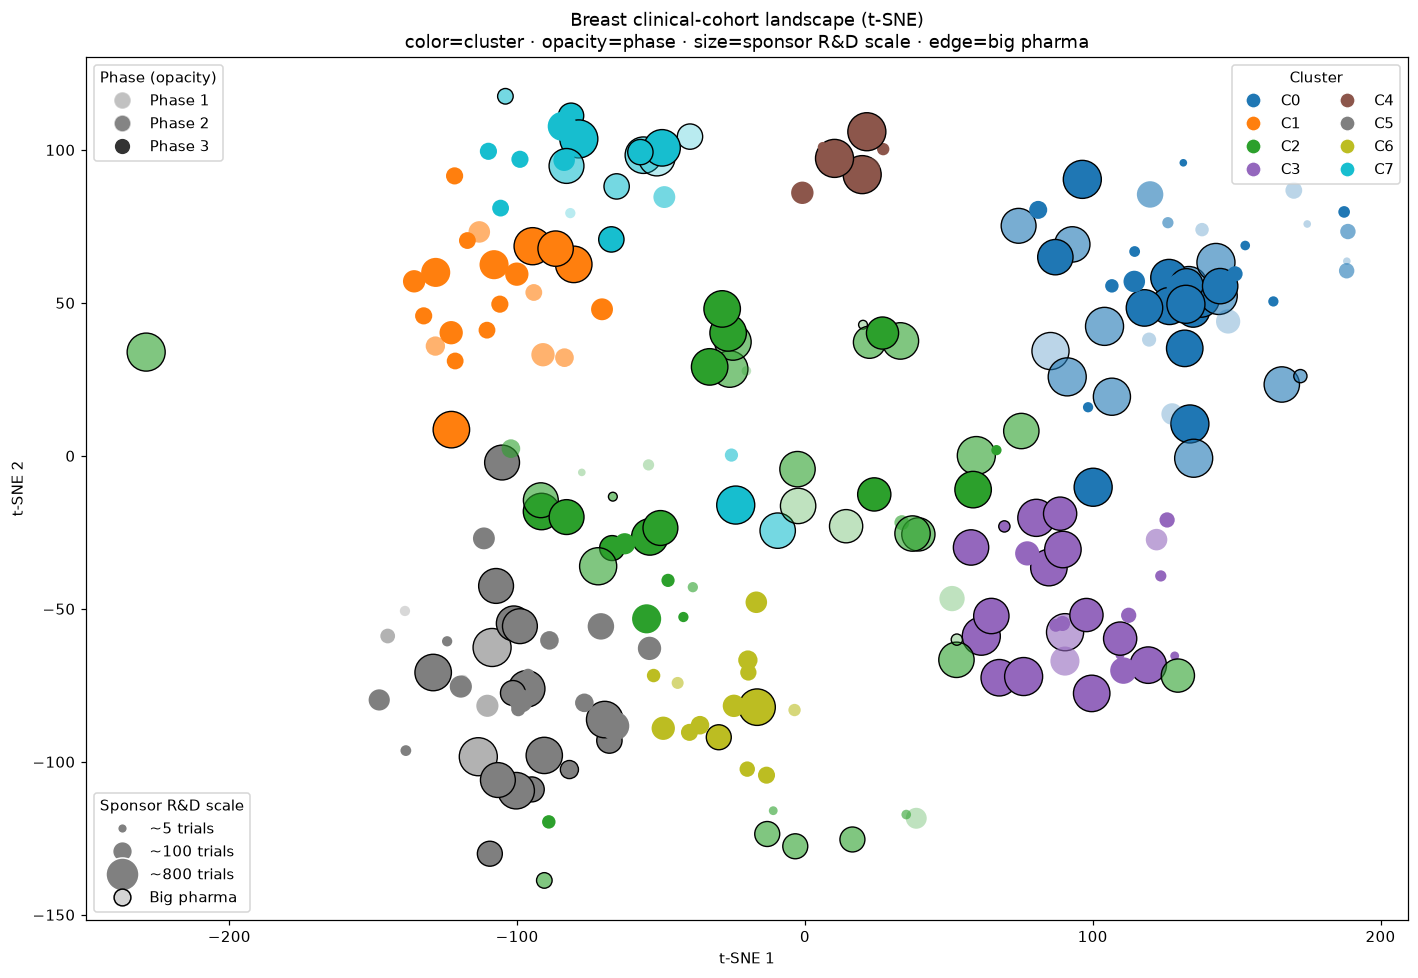

In [9]:
from matplotlib.lines import Line2D
palette = plt.cm.tab10(np.linspace(0,1,df.cluster.nunique()))
PHASE_ALPHA = {"Phase 1":0.3, "Phase 2":0.6, "Phase 3":1.0}

scale = df.sponsor_scale.fillna(1).clip(lower=1).values
smin, smax = np.sqrt(scale.min()), np.sqrt(scale.max())
sizes = np.interp(np.sqrt(scale), [smin, smax], [25, 620])

face = np.array([list(palette[c]) for c in df.cluster])
face[:,3] = df.phase_simple.map(PHASE_ALPHA).fillna(0.3).values
edge = np.where(df.is_big_pharma.values==1, "black", "none")

fig, ax = plt.subplots(figsize=(13,9))
ax.scatter(df.x, df.y, s=sizes, facecolors=face, edgecolors=edge, linewidths=0.9, marker="o")

cl_leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor=palette[c], markersize=10, label=f"C{c}") for c in sorted(df.cluster.unique())]
ph_leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor=(0.2,0.2,0.2,a), markersize=11, label=p) for p,a in PHASE_ALPHA.items()]
ref = [5, 100, 800]
sz_leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor="gray",
          markersize=np.sqrt(np.interp(np.sqrt(v),[smin,smax],[25,620]))*0.9,
          label=f"~{v} trials") for v in ref]
bp_leg = [Line2D([0],[0], marker="o", color="w", markerfacecolor="lightgray", markeredgecolor="black", markersize=11, label="Big pharma")]
leg1 = ax.legend(handles=ph_leg, title="Phase (opacity)", loc="upper left"); ax.add_artist(leg1)
leg2 = ax.legend(handles=sz_leg+bp_leg, title="Sponsor R&D scale", loc="lower left"); ax.add_artist(leg2)
ax.legend(handles=cl_leg, title="Cluster", loc="upper right", ncol=2)
ax.set_title(f"{CANCER} clinical-cohort landscape (t-SNE)\ncolor=cluster · opacity=phase · size=sponsor R&D scale · edge=big pharma")
ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
plt.tight_layout()
(ROOT/"outputs").mkdir(exist_ok=True)
plt.savefig(ROOT/"outputs"/f"cohort_map_{SLUG}.png", dpi=140, bbox_inches="tight")
plt.show()

## 5-B. 클러스터별 대표 빅파마 코호트

각 클러스터의 중심(군집 특성공간)에서 **가장 가까운 빅파마 코호트**를 대표로 뽑아 코호트 정의를
정리한다. 대표 제약사·대조군 치료(B)·바이오마커와, 그 클러스터에 함께 속한 다른 제약사들을 표로.

In [10]:
BM_COLS = [c for c in BM_COLS_ALL if c in df]
rep_rows = []
for c in sorted(df.cluster.unique()):
    idx = np.array(df.index[df.cluster==c])
    center = EMB[idx].mean(axis=0)
    bp_idx = [i for i in idx if df.loc[i,"is_big_pharma"]==1]
    pool = bp_idx if bp_idx else list(idx)
    rep = min(pool, key=lambda i: np.linalg.norm(EMB[i]-center))
    r = df.loc[rep]
    bms = [b for b in BM_COLS if r.get(b,0)==1]
    others = [s for s in dict.fromkeys(df.loc[idx,"lead_sponsor"].dropna()) if s != r.lead_sponsor]
    rep_rows.append({
        "cluster": c, "n": len(idx),
        "대표 제약사": r.lead_sponsor + ("" if bp_idx else " (빅파마 없음·최근접)"),
        "대조군 치료 B": r.B_soc or "-",
        "바이오마커": ", ".join(bms) or "-",
        "phase": r.phase_simple,
        "대표 NCT": r.nct_id,
        "다른 제약사": ", ".join(others[:8]) + (" …" if len(others) > 8 else "") or "-",
    })
rep_tbl = pd.DataFrame(rep_rows)
rep_tbl.to_csv(ROOT/"outputs"/f"cluster_representatives_{SLUG}.csv", index=False)
print(f"saved outputs/cluster_representatives_{SLUG}.csv")
import pandas as _pd; _pd.set_option("display.max_colwidth", 60)
rep_tbl

saved outputs/cluster_representatives_breast.csv


,cluster,n,대표 제약사,대조군 치료 B,바이오마커,phase,대표 NCT,다른 제약사
0,0,54,AstraZeneca,fluorouracil;fulvestrant,HR/ER,Phase 3,NCT00099437,"Eli Lilly and Company, Phoenix Molecular Designs, Hoffma..."
1,1,21,Novartis Pharmaceuticals,pertuzumab;trastuzumab,"HER2, PIK3CA",Phase 3,NCT04208178,"AstraZeneca, Seagen, a wholly owned subsidiary of Pfizer..."
2,2,50,AstraZeneca,capecitabine;carboplatin;cyclophosphamide;doxorubicin;ep...,"HR/ER, HER2",Phase 3,NCT06112379,"US Oncology Research, Hoffmann-La Roche, Eli Lilly and C..."
3,3,26,Eli Lilly and Company,anastrozole;letrozole,"HR/ER, HER2",Phase 3,NCT02246621,"Novartis Pharmaceuticals, Hoffmann-La Roche, AstraZeneca..."
4,4,7,Hoffmann-La Roche,standard_of_care,"HR/ER, HER2",Phase 3,NCT04961996,"OBI Pharma, Inc, BriaCell Therapeutics Corporation, Qilu..."
5,5,35,AstraZeneca,capecitabine;nab-paclitaxel;paclitaxel,"HR/ER, HER2",Phase 3,NCT04494425,"Daehwa Pharmaceutical Co., Ltd., Hoffmann-La Roche, Merc..."
6,6,14,Gilead Sciences,capecitabine;eribulin;gemcitabine;vinorelbine,"HR/ER, HER2",Phase 3,NCT04639986,"AstraZeneca, CSPC ZhongQi Pharmaceutical Technology Co.,..."
7,7,21,US Oncology Research,trastuzumab,HER2,Phase 2,NCT03379428,"Daiichi Sankyo, AstraZeneca, Pfizer, Hoffmann-La Roche, ..."


## 5-C. 인터랙티브 코호트 대시보드 (HTML)

`outputs/cohort_map_<slug>.html` — 좌: 코호트 맵, 우: ① 클러스터별 정보, ② **R&D 규모순 제약사
드롭다운** → 선택 시 맵에서 위치 하이라이트 + 그 제약사 임상의 ClinicalTrials.gov 링크·상세 카드.
맵의 점 클릭·hover(제약사·레지멘·Phase·status)도 지원.

In [11]:
from interactive_map import build_interactive
out = build_interactive(df, rep_tbl, palette, BM_COLS, ROOT/"outputs"/f"cohort_map_{SLUG}.html")
print("saved", out)

saved /Users/minsung.choi/clinical_data_finder/outputs/cohort_map_breast.html


## 6. 가치 랭킹 — 표준치료 B 데이터 자산 (수요 폭 중심)

각 B에 대해: **demand_breadth**(그 B를 쓰는 진행 중 트라이얼 수, 주축) + 스폰서 다양성 +
빅파마 수 + phase 가중 + 등록 규모 + TME 관련성 + 바이오마커 개방성.

In [12]:
PH_W = {"Phase 3":3.0, "Phase 2":1.6, "Phase 1":1.0}
rows = []
b_lists = df.B_soc.fillna("").apply(lambda s:[x for x in s.split(";") if x])
all_b = sorted({x for l in b_lists for x in l})
for b in all_b:
    mask = b_lists.apply(lambda l: b in l)
    sub = df[mask]
    if len(sub) < 2:
        continue
    rows.append({
        "B (standard therapy)": b,
        "demand_breadth": len(sub),
        "sponsors": sub.lead_sponsor.nunique(),
        "bigpharma": int(sub.is_big_pharma.sum()),
        "phase_weight": round(sub.phase_simple.map(PH_W).sum(),1),
        "n_phase3": int((sub.phase_simple=="Phase 3").sum()),
        "enroll_sum": int(sub.enrollment.fillna(0).sum()),
        "tme_rel%": round(100*sub.tme_relevant.mean()),
        "biomarker%": round(100*sub.biomarker_selected.mean()),
    })
rank = pd.DataFrame(rows)
def nz(s): return (s - s.min())/(s.max()-s.min()+1e-9)
rank["value_score"] = (0.45*nz(rank.demand_breadth) + 0.15*nz(rank.sponsors) + 0.12*nz(rank.bigpharma)
                       + 0.13*nz(rank.phase_weight) + 0.07*nz(np.log1p(rank.enroll_sum))
                       + 0.05*nz(rank["tme_rel%"]) + 0.03*nz(rank["biomarker%"]))
rank = rank.sort_values("value_score", ascending=False).reset_index(drop=True)
rank.to_csv(ROOT/"outputs"/f"value_ranking_{SLUG}.csv", index=False)
rank.head(15)

,B (standard therapy),demand_breadth,sponsors,bigpharma,phase_weight,n_phase3,enroll_sum,tme_rel%,biomarker%,value_score
0,fluorouracil,59,33,29,135.8,33,19964,3,92,0.939612
1,fulvestrant,53,28,29,126.6,32,19116,0,94,0.859034
2,paclitaxel,44,25,21,116.8,34,26435,89,89,0.776429
3,capecitabine,43,26,20,119.2,36,27228,86,98,0.775661
4,trastuzumab,45,20,20,110.8,29,21247,84,98,0.751314
5,nab-paclitaxel,24,14,15,67.8,21,14259,96,96,0.495018
6,letrozole,27,15,15,75.4,23,37290,0,85,0.487113
7,gemcitabine,21,17,9,61.6,20,10346,90,95,0.447278
8,carboplatin,20,14,11,55.8,17,15527,90,100,0.435542
9,pertuzumab,22,13,6,57.6,16,12217,82,95,0.417991


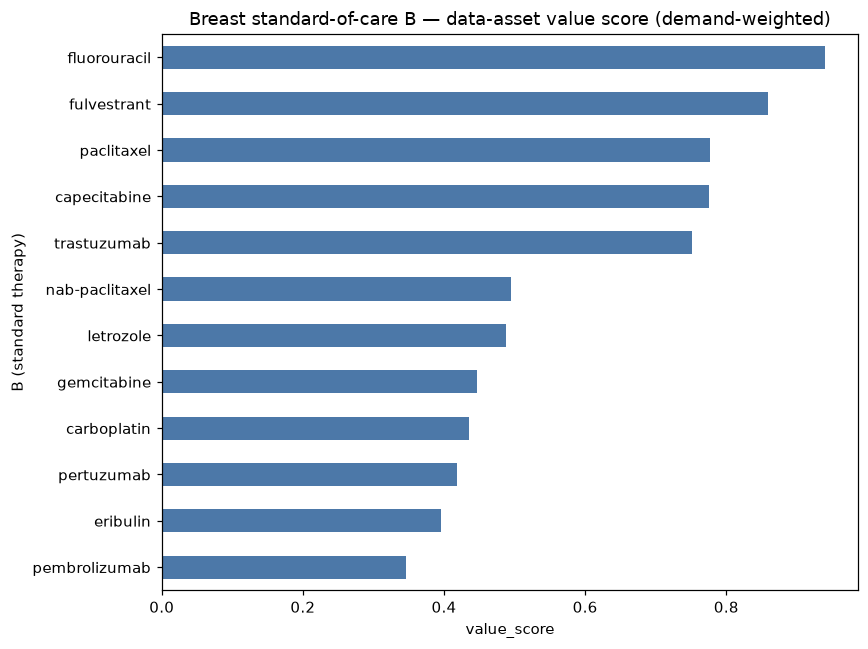

In [13]:
top = rank.head(12).iloc[::-1]
ax = top.set_index("B (standard therapy)")["value_score"].plot.barh(figsize=(8,6), color="#4C78A8")
ax.set_title(f"{CANCER} standard-of-care B — data-asset value score (demand-weighted)")
ax.set_xlabel("value_score"); plt.tight_layout()
plt.savefig(ROOT/"outputs"/f"value_ranking_{SLUG}.png", dpi=140, bbox_inches="tight"); plt.show()

## 7. 먼저 접근할 코호트 — 빅파마 참여 + Phase 3 우선

In [14]:
priority = df[(df.is_big_pharma==1)].copy()
priority["ph_rank"] = priority.phase_simple.map({"Phase 3":3,"Phase 2":2,"Phase 1":1})
priority = priority.sort_values(["ph_rank","enrollment"], ascending=False)
cols = ["nct_id","phase_simple","lead_sponsor","B_soc","targets","enrollment","arm_structure","biomarker_selected"]
priority[cols].head(20)

,nct_id,phase_simple,lead_sponsor,B_soc,targets,enrollment,arm_structure,biomarker_selected
84,NCT05514054,Phase 3,Eli Lilly and Company,anastrozole;exemestane;letrozole;tamoxifen,ESR1,8000,active_comparator,1
9,NCT03155997,Phase 3,Eli Lilly and Company,abemaciclib,CDK4/6,5637,multi_experimental,1
108,NCT05952557,Phase 3,AstraZeneca,abemaciclib;anastrozole;exemestane;letrozole;tamoxifen,CDK4/6,5511,active_comparator,1
94,NCT05774951,Phase 3,AstraZeneca,anastrozole;exemestane;letrozole;tamoxifen,ESR1,4300,active_comparator,1
56,NCT04961996,Phase 3,Hoffmann-La Roche,standard_of_care,ESR1,4170,active_comparator,1
170,NCT06966700,Phase 3,Merck Sharp & Dohme LLC,capecitabine;carboplatin;cyclophosphamide;doxorubicin;ep...,PD-1,2400,active_comparator,1
119,NCT06112379,Phase 3,AstraZeneca,capecitabine;carboplatin;cyclophosphamide;doxorubicin;ep...,TROP1,1902,active_comparator,1
132,NCT06393374,Phase 3,Merck Sharp & Dohme LLC,capecitabine;pembrolizumab,PD-1,1530,active_comparator,1
88,NCT05633654,Phase 3,Gilead Sciences,capecitabine;pembrolizumab,PD-1,1514,active_comparator,1
97,NCT05827081,Phase 3,Novartis Pharmaceuticals,exemestane;goserelin;letrozole;leuprolide;ribociclib,CDK4/6,1400,single_arm,1


## 8. 요약

- **가치 랭킹(`outputs/value_ranking_breast.csv`)**: 유방암(Breast)에서 TME 데이터를 만들면 가장 많은 스폰서가 원할 표준치료 B 순위.
- **코호트 맵/대시보드(`outputs/cohort_map_breast.png` / `.html`)**: 제약사들이 집중하는 코호트 아키타입 분포, Phase·빅파마 강조.
- **먼저 접근할 코호트**: 빅파마 참여 + Phase 3 pivotal 우선.